<a href="https://colab.research.google.com/github/NosyrevAI/refactored-robot/blob/main/%D0%9B%D0%BE%D0%B3%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D1%8F_%D0%B8_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Логистическая регрессия и SVM**

In [ ]:
# 1. Загрузка библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [ ]:
# Настройка стиля графиков
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
# 2. Загрузка данных
df = pd.read_csv('adult.csv')

In [ ]:
# 3. Первичный просмотр
print("Первые 5 строк:")
display(df.head())

print("\nИнформация о данных:")
df.info()

print("\nОписательная статистика числовых признаков:")
display(df.describe())

print("\nКоличество уникальных значений в категориальных признаках:")
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].nunique()} уникальных значений")

Первые 5 строк:


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB

Описательная статистика числовых признаков:


,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000



Количество уникальных значений в категориальных признаках:
workclass: 9 уникальных значений
education: 16 уникальных значений
marital-status: 7 уникальных значений
occupation: 15 уникальных значений
relationship: 6 уникальных значений
race: 5 уникальных значений
gender: 2 уникальных значений
native-country: 42 уникальных значений
income: 2 уникальных значений


In [ ]:
# 4. Обработка пропусков
# В данных пропуски обозначены знаком '?'.
# Посмотрим, есть ли такие значения
print("\nПризнаки, содержащие '?':")
for col in df.columns:
    if df[col].dtype == 'object':
        missing = (df[col] == '?').sum()
        if missing > 0:
            print(f"{col}: {missing} пропусков ('?')")


Признаки, содержащие '?':
workclass: 2799 пропусков ('?')
occupation: 2809 пропусков ('?')
native-country: 857 пропусков ('?')


In [ ]:
# Заменяем '?' на NaN для удобства обработки
df.replace('?', np.nan, inplace=True)


In [ ]:
# Проверим количество пропусков после замены
print("\nКоличество NaN после замены '?':")
print(df.isna().sum())


Количество NaN после замены '?':
age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64


In [ ]:
# Удаляем строки с пропусками
df_clean = df.dropna().copy()
print(f"\nРазмер данных после удаления пропусков: {df_clean.shape}")


Размер данных после удаления пропусков: (45222, 15)


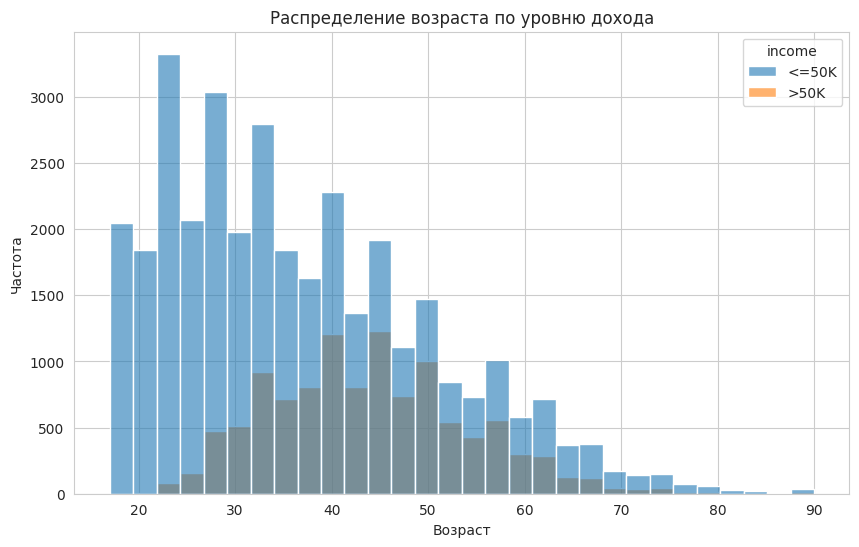

In [ ]:
# 5. Визуализация
# Построим несколько графиков, чтобы понять распределение признаков относительно целевой переменной.

# Целевая переменная: income
# Посмотрим распределение возраста для разных уровней дохода
plt.figure()
sns.histplot(data=df_clean, x='age', hue='income', bins=30, alpha=0.6)
plt.title('Распределение возраста по уровню дохода')
plt.xlabel('Возраст')
plt.ylabel('Частота')
plt.show()

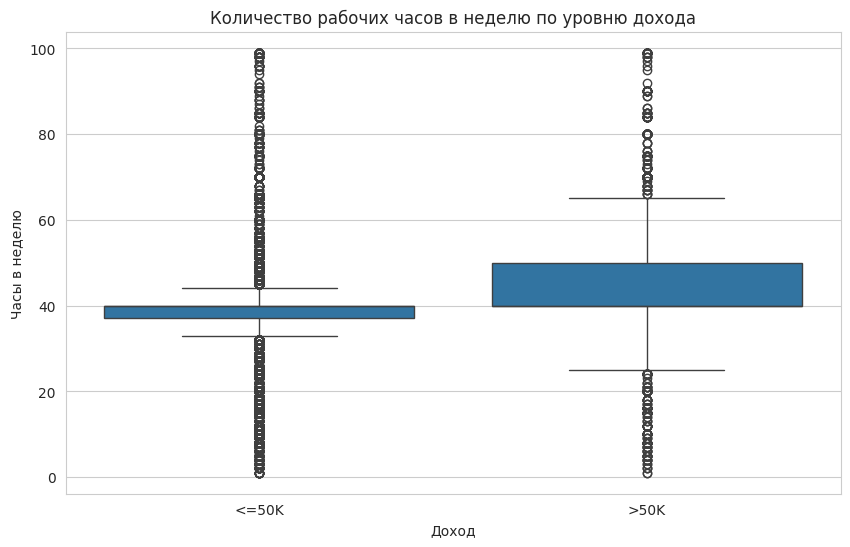

In [ ]:
# График количества рабочих часов в неделю для двух классов
plt.figure()
sns.boxplot(data=df_clean, x='income', y='hours-per-week')
plt.title('Количество рабочих часов в неделю по уровню дохода')
plt.xlabel('Доход')
plt.ylabel('Часы в неделю')
plt.show()


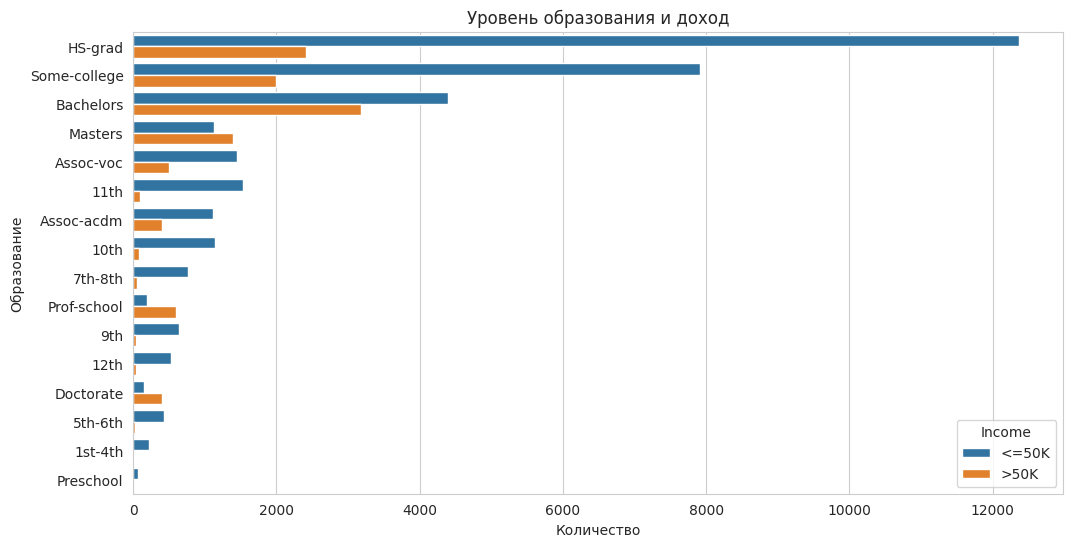

In [ ]:
# Можно также посмотреть распределение образования (education) – столбчатая диаграмма
plt.figure(figsize=(12,6))
sns.countplot(data=df_clean, y='education', hue='income', order=df_clean['education'].value_counts().index)
plt.title('Уровень образования и доход')
plt.xlabel('Количество')
plt.ylabel('Образование')
plt.legend(title='Income')
plt.show()

In [ ]:
# 6. Преобразование категориальных признаков
# Отделим целевую переменную и признаки.
X = df_clean.drop('income', axis=1)
y = df_clean['income']

In [ ]:
# Кодируем целевую переменную в числовой формат: 0 для <=50K, 1 для >50K
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # <=50K -> 0, >50K -> 1
print("\nЦелевая переменная закодирована: ", dict(zip(le.classes_, le.transform(le.classes_))))


Целевая переменная закодирована:  {'<=50K': np.int64(0), '>50K': np.int64(1)}


In [ ]:
# Определим категориальные столбцы (объектного типа)
categorical_cols = X.select_dtypes(include='object').columns.tolist()
print("Категориальные признаки:", categorical_cols)

Категориальные признаки: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']


In [ ]:
# Применяем One-Hot Encoding (pd.get_dummies)
# Для больших данных можно использовать параметр drop_first=True, чтобы избежать мультиколлинеарности,
# но в случае логистической регрессии и SVM это не обязательно, но допустимо.
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print(f"\nРазмер матрицы признаков после кодирования: {X_encoded.shape}")


Размер матрицы признаков после кодирования: (45222, 96)


In [ ]:
# 7. Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded,
                                                    test_size=0.2, random_state=42, stratify=y_encoded)
print(f"\nОбучающая выборка: {X_train.shape}, тестовая: {X_test.shape}")


Обучающая выборка: (36177, 96), тестовая: (9045, 96)


In [ ]:
# 8. Масштабирование признаков
# Для моделей, чувствительных к масштабу (логистическая регрессия с регуляризацией и SVM), важно отмасштабировать данные.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# 9. Обучение модели логистической регрессии
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"\nТочность логистической регрессии на тесте: {acc_lr:.4f}")


Точность логистической регрессии на тесте: 0.8458


In [ ]:
# 10. Обучение модели опорных векторов (SVM)
svm_model = SVC(kernel='rbf', random_state=42)  # Радиальное ядро по умолчанию
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"Точность SVM на тесте: {acc_svm:.4f}")

Точность SVM на тесте: 0.8423


In [ ]:
# 11. Выводы
print("\n" + "="*50)
print("ВЫВОДЫ")
print("="*50)
print("""
a) Преобразования данных:
   - Заменили символы '?' на NaN и удалили строки с пропусками (альтернативно можно было заполнить модой).
   - Категориальные признаки преобразованы методом One-Hot Encoding.
   - Целевая переменная закодирована в 0 и 1.
   - Проведено масштабирование числовых признаков с помощью StandardScaler.

b) Сравнение точности моделей:
   - Логистическая регрессия: {:.4f}
   - Метод опорных векторов (SVM с RBF-ядром): {:.4f}
   Обе модели показали близкую точность, SVM незначительно превосходит логистическую регрессию на данных после масштабирования.

c) Мнение о качестве моделей:
   Модели справились с задачей на уровне ~85% правильных ответов. Это неплохой результат для базовых моделей без настройки
   гиперпараметров. Однако остаётся около 15% ошибок, что может быть связано с дисбалансом классов (в данных больше людей с
   доходом <=50K) и наличием сложных нелинейных зависимостей.


""".format(acc_lr, acc_svm))


ВЫВОДЫ

a) Преобразования данных:
   - Заменили символы '?' на NaN и удалили строки с пропусками (альтернативно можно было заполнить модой).
   - Категориальные признаки преобразованы методом One-Hot Encoding.
   - Целевая переменная закодирована в 0 и 1.
   - Проведено масштабирование числовых признаков с помощью StandardScaler.

b) Сравнение точности моделей:
   - Логистическая регрессия: 0.8458
   - Метод опорных векторов (SVM с RBF-ядром): 0.8423
   Обе модели показали близкую точность, SVM незначительно превосходит логистическую регрессию на данных после масштабирования.

c) Мнение о качестве моделей:
   Модели справились с задачей на уровне ~85% правильных ответов. Это неплохой результат для базовых моделей без настройки 
   гиперпараметров. Однако остаётся около 15% ошибок, что может быть связано с дисбалансом классов (в данных больше людей с 
   доходом <=50K) и наличием сложных нелинейных зависимостей.



